# ERA Prediction Simulator (Week 14 Capstone)

## Steo 1 - Import FanGraphs Data

In [90]:
import pandas as pd

modeling_years = [2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

# Importing Standard Stats
standard_stats = pd.DataFrame()

for year in modeling_years:

  path = f"standard_pitcher_stats_{year}.csv"
  df = pd.read_csv(path)

  df['year'] = year

  standard_stats = pd.concat([standard_stats, df], ignore_index=True)

# Importing Statcast Stats
statcast_stats = pd.DataFrame()

for year in modeling_years:

  path = f"statcast_pitcher_stats_{year}.csv"
  df = pd.read_csv(path)

  df['year'] = year

  statcast_stats = pd.concat([statcast_stats, df], ignore_index=True)

# Importing plus Stats
plus_stats = pd.DataFrame()

for year in modeling_years:

  path = f"plus_pitcher_stats_{year}.csv"
  df = pd.read_csv(path)

  df['year'] = year

  plus_stats = pd.concat([plus_stats, df], ignore_index=True)


print(len(standard_stats))
print(len(statcast_stats))
print(len(plus_stats))

2868
2868
2868


In [91]:
# Before any merging or feature selection
# Just correlate current year ERA with next year ERA directly
df_sorted = standard_stats.sort_values(['PlayerId', 'year'])
df_sorted['next_era'] = df_sorted.groupby('PlayerId')['ERA'].shift(-1)
print(df_sorted[['ERA', 'next_era']].corr())

               ERA  next_era
ERA       1.000000  0.203394
next_era  0.203394  1.000000


## Step 2 - Removing duplicate columns Across DataFrames

In [92]:
standard_cols = set(standard_stats.columns)
statcast_cols = set(statcast_stats.columns)
plus_cols = set(plus_stats.columns)

# Removing All duplicate columns which are located in standard from statcast and plus (excluding PlayerId, year)
for col in standard_cols:

  if col != 'PlayerId' and col != 'year':

    if col in statcast_cols:
      statcast_stats.drop(columns=[col], inplace=True)
    if col in plus_cols:
      plus_stats.drop(columns=[col], inplace=True)

# Removing All duplicate columns which are located in statcast from plus (excluding PlayerId, year)
statcast_cols = set(statcast_stats.columns)
plus_cols = set(plus_stats.columns)
for col in statcast_cols:

  if col != 'PlayerId' and col != 'year':

    if col in plus_cols:
      plus_stats.drop(columns=[col], inplace=True)



## Step 3 - Joining DataFrames and leading ERA

In [93]:
from os import stat
# Extracting ERA information for forward prediction
y_info = standard_stats[['PlayerId', 'year', 'ERA']]
y_info.rename(columns={'year': 'join_year'}, inplace=True)
standard_stats.drop(columns='ERA', inplace=True)

unique_id = ['PlayerId', 'year']
# Joining Standard and statcast dataframes on 'PlayerId', 'year'
pitcher_stats = pd.merge(standard_stats, statcast_stats, on=unique_id, how='inner')

# Joining pitcher_stats with plus dataframe on 'PlayerId', 'year'
pitcher_stats = pitcher_stats.merge(plus_stats, on=unique_id, how='inner')

# Dropping 2025 rows since they have no target data
pitcher_stats = pitcher_stats.loc[pitcher_stats['year'] != 2025]

# adding leading year and merging with ERA data
pitcher_stats['join_year'] = pitcher_stats['year'] + 1
pitcher_stats = pitcher_stats.merge(y_info, on=['join_year', 'PlayerId'], how='inner')
pitcher_stats.drop(columns=['join_year'], inplace=True)


pitcher_stats.head()

/tmp/ipykernel_9627/1563532200.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_info.rename(columns={'year': 'join_year'}, inplace=True)


,Name,Team,W,L,G,GS,QS,CG,ShO,SV,...,WHIP+,BABIP+,LOB%+,ERA-,FIP-,xFIP-,LD%+,GB%+,FB%+,ERA
0,Max Scherzer,WSN,18,7,33,33,28,2,1,0,...,70.299853,90.626928,111.121617,61.711575,63.961433,75.147255,83.378313,77.922406,138.911353,2.924565
1,Justin Verlander,HOU,16,9,34,34,26,1,1,0,...,68.734681,92.323447,117.701978,61.547311,67.446030,71.890630,92.251658,68.534923,141.116835,2.582960
2,Gerrit Cole,HOU,15,5,32,32,20,1,1,0,...,78.749811,97.080876,107.514357,70.129118,65.513920,71.915754,100.932642,84.781474,117.170153,2.500785
3,Jacob deGrom,NYM,10,9,32,32,28,1,0,0,...,70.420732,96.314515,112.085527,44.615312,49.275632,63.726253,100.800975,105.587487,92.315979,2.426471
4,Patrick Corbin,ARI,11,7,33,33,19,1,1,0,...,81.037197,103.603837,102.151775,77.302949,61.793765,63.881418,111.871962,110.244202,79.302119,3.252475


## Step 4 - Data Exploration

In [94]:
pitcher_stats.describe()

,W,L,G,GS,QS,CG,ShO,SV,HLD,BS,...,WHIP+,BABIP+,LOB%+,ERA-,FIP-,xFIP-,LD%+,GB%+,FB%+,ERA
count,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,...,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000,1475.000000
mean,6.065763,5.537627,36.515932,13.774237,5.658983,0.133559,0.071186,2.570169,4.113220,1.157288,...,96.197044,98.698004,102.278566,92.548197,94.089700,95.307106,98.877893,101.429684,98.966612,4.017788
std,4.062990,3.313418,19.013356,12.201325,6.584152,0.441018,0.279956,7.214465,7.095305,1.969494,...,15.683523,11.716539,8.945322,27.772885,21.618294,16.810719,13.700591,18.665922,21.071269,1.227625
min,0.000000,0.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,42.869107,55.208231,61.827168,15.231968,28.764206,37.394555,47.545135,45.240405,27.966704,0.605381
25%,3.000000,3.000000,23.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,85.512237,91.607441,96.554771,74.573324,79.441922,84.291428,90.450322,89.002066,86.008342,3.176471
50%,5.000000,5.000000,31.000000,12.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,95.266997,99.002388,102.463969,90.251863,93.120315,95.777865,98.783069,100.434256,99.323041,3.898396
75%,8.000000,8.000000,55.000000,26.000000,10.000000,0.000000,0.000000,1.000000,6.000000,2.000000,...,106.156916,106.292235,107.917087,107.753457,108.243921,106.428514,107.999238,112.642124,112.016650,4.734071
max,21.000000,19.000000,81.000000,35.000000,28.000000,6.000000,2.000000,57.000000,38.000000,13.000000,...,163.561692,146.322623,138.959378,231.968209,168.806422,151.605429,145.127937,180.198217,174.342797,9.576357


In [95]:
pitcher_stats.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1475 entries, 0 to 1474
Data columns (total 55 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Name       1475 non-null   object 
 1   Team       1475 non-null   object 
 2   W          1475 non-null   int64  
 3   L          1475 non-null   int64  
 4   G          1475 non-null   int64  
 5   GS         1475 non-null   int64  
 6   QS         1475 non-null   int64  
 7   CG         1475 non-null   int64  
 8   ShO        1475 non-null   int64  
 9   SV         1475 non-null   int64  
 10  HLD        1475 non-null   int64  
 11  BS         1475 non-null   int64  
 12  IP         1475 non-null   float64
 13  TBF        1475 non-null   int64  
 14  H          1475 non-null   int64  
 15  R          1475 non-null   int64  
 16  ER         1475 non-null   int64  
 17  HR         1475 non-null   int64  
 18  BB         1475 non-null   int64  
 19  IBB        1475 non-null   int64  
 20  HBP     

## Step 5 - Redundant Feature Removal


In [96]:
# Removing fields which are directly calculated with ERA
pitcher_stats.drop(columns=['ERA-', 'ER', 'R', 'xERA'], inplace=True)

# Removing Columns which are correlated more with opportunity and luck than skill.
pitcher_stats.drop(columns=['W', 'L', 'CG', 'ShO', 'BS', 'HLD', 'SV', 'BK', 'WP', 'IBB', 'TBF', 'Events', 'BABIP+', 'LOB%+'], inplace=True)

# Removing columns which have rate statistics (ex. HR/9)
pitcher_stats.drop(columns=['H', 'BB', 'HR', 'SO', 'HBP', 'Barrels', 'HardHit'], inplace=True)


## Step 6 - EDA

In [97]:
pitcher_stats.columns

Index(['Name', 'Team', 'G', 'GS', 'QS', 'IP', 'NameASCII', 'PlayerId',
       'MLBAMID', 'year', 'EV', 'EV90', 'maxEV', 'LA', 'Barrel%', 'HardHit%',
       'K/9+', 'BB/9+', 'K/BB+', 'HR/9+', 'K%+', 'BB%+', 'AVG+', 'WHIP+',
       'FIP-', 'xFIP-', 'LD%+', 'GB%+', 'FB%+', 'ERA'],
      dtype='object')

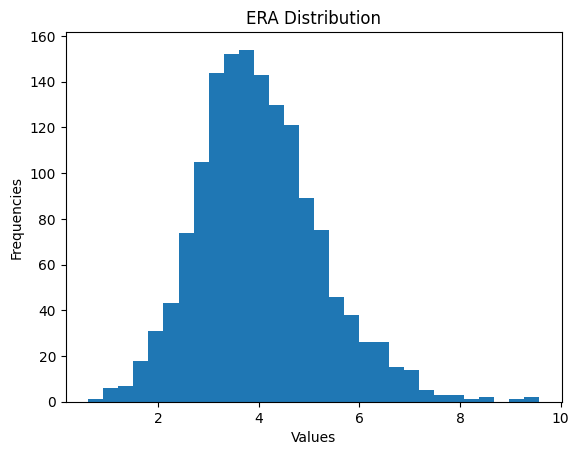

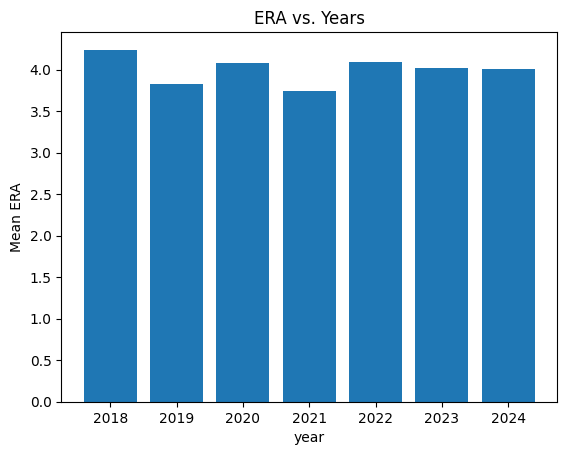

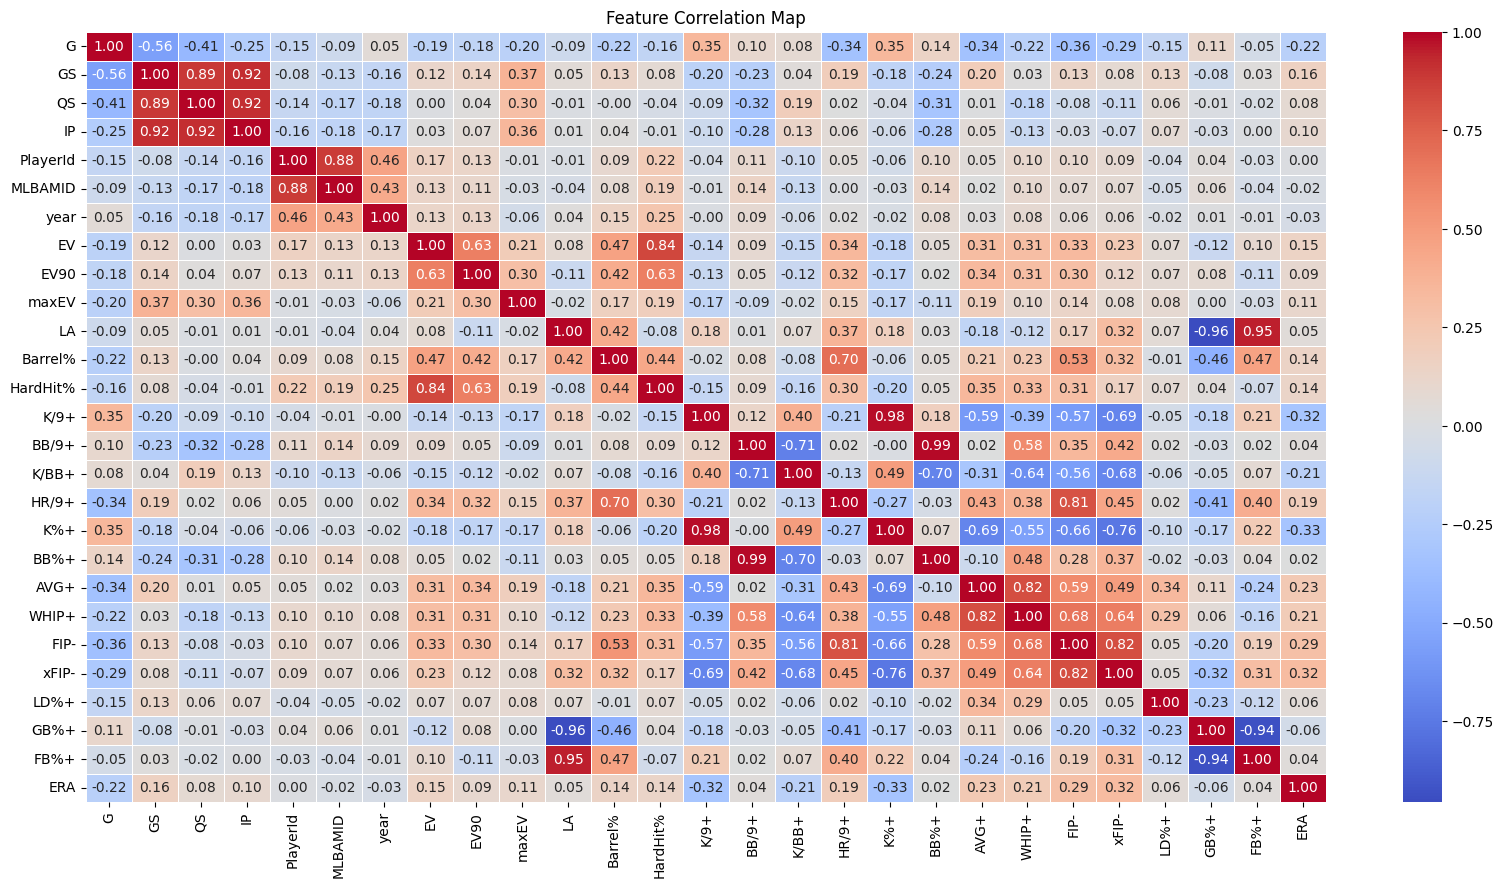

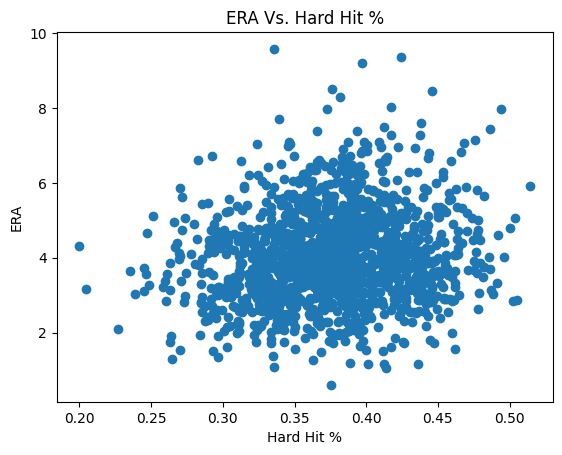

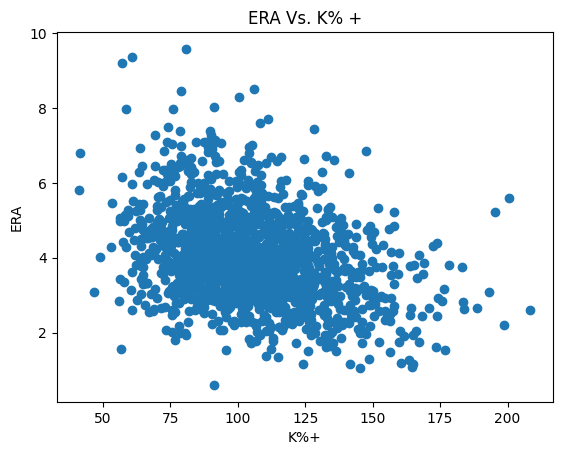

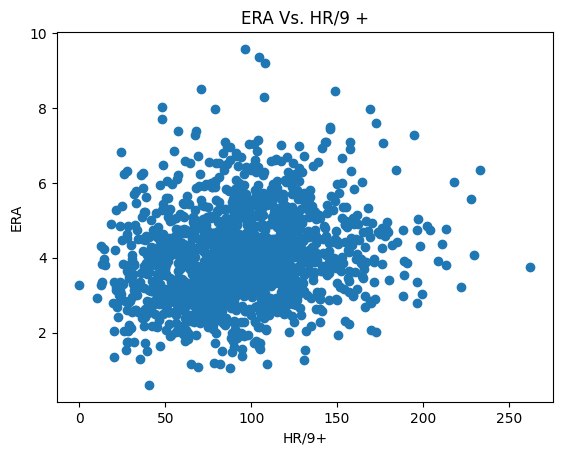

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Plotting ERA distribution
plt.hist(pitcher_stats['ERA'], bins=30)
plt.title("ERA Distribution")
plt.xlabel("Values")
plt.ylabel("Frequencies")
plt.show()

# Plotting mean ERA vs years
years = pitcher_stats.groupby(['year'])['ERA'].mean().reset_index()
plt.bar(years['year'], years['ERA'])
plt.xlabel('year')
plt.ylabel('Mean ERA')
plt.title('ERA vs. Years')
plt.show()

# Plotting Correlation Heatmap
matrix = pitcher_stats.select_dtypes(np.number).corr()
plt.figure(figsize=(20,10))
sns.heatmap(matrix,  cmap = 'coolwarm', annot=True, fmt='.2f', linewidths=.5)
plt.title("Feature Correlation Map")
plt.show()

# ERA Vs. HardHit%
plt.scatter(pitcher_stats['HardHit%'], pitcher_stats['ERA'])
plt.title("ERA Vs. Hard Hit %")
plt.xlabel("Hard Hit %")
plt.ylabel("ERA")
plt.show()

# ERA Vs. K%+
plt.scatter(pitcher_stats["K%+"], pitcher_stats['ERA'])
plt.title("ERA Vs. K% +")
plt.xlabel("K%+")
plt.ylabel("ERA")
plt.show()

# ERA Vs. HR/9+
plt.scatter(pitcher_stats["HR/9+"], pitcher_stats['ERA'])
plt.title("ERA Vs. HR/9 +")
plt.xlabel("HR/9+")
plt.ylabel("ERA")
plt.show()

## Step 6 - Feature Multicolinearity Check

In [99]:
# Dropping Obviously Correlated features (Keeping feature with higher correlation to ERA)
pitcher_stats.drop(columns=['K/9+', 'BB%+'], inplace=True)

In [100]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Running VIF and iteratively removing features with scores greater than 10
X = pitcher_stats.drop(columns=['Name', 'Team', 'NameASCII', 'PlayerId', 'MLBAMID', 'ERA'])
feature_names = X.columns

vif_data = pd.DataFrame({
    'Feature Name': feature_names,
    'vif': [variance_inflation_factor(X, i)
    for i in range(X.shape[1])]
}).sort_values(by='vif', ascending=False)

vif_data

,Feature Name,vif
4,year,81402.033406
6,EV90,18574.493199
5,EV,13510.033378
20,GB%+,12284.512498
21,FB%+,8848.195495
16,WHIP+,5635.751605
15,AVG+,4820.725331
7,maxEV,2749.955519
18,xFIP-,2722.567928
19,LD%+,2592.994430


Columns Dropped From VIF and there scores:
- year: 81402.03
- EV90: 16898.50
- FB%+: 2620.84
- FIP-: 1489.19
- maxEV: 2424.32
- WHIP+: 5211.82
- AVG+: 4603.39
- BB/9+: 537.14
- EV: 3528.42
- GB%+: 502.03
- Barrel%: 30.74
- G: 24.47
- GS: 57.64

Need to keep 'year' for train/validation/test set creation

In [101]:
pitcher_stats.drop(columns=['EV90', 'FB%+', 'FIP-', 'maxEV', 'WHIP+', 'AVG+', 'BB/9+', 'EV', 'GB%+', 'Barrel%', 'G', 'GS'], inplace=True)

## Step 7 - Train, Validation, Test

In [102]:
pitcher_stats.columns

Index(['Name', 'Team', 'QS', 'IP', 'NameASCII', 'PlayerId', 'MLBAMID', 'year',
       'LA', 'HardHit%', 'K/BB+', 'HR/9+', 'K%+', 'xFIP-', 'LD%+', 'ERA'],
      dtype='object')

In [103]:
train = pitcher_stats.loc[pitcher_stats['year'] < 2023]
validation = pitcher_stats.loc[pitcher_stats['year'] == 2023]
test = pitcher_stats.loc[pitcher_stats['year'] == 2024]

X_train = train.drop(columns=['Name', 'Team', 'NameASCII', 'PlayerId','MLBAMID', 'year', 'ERA'])
y_train = train['ERA']

X_validation = validation.drop(columns=['Name', 'Team', 'NameASCII', 'PlayerId','MLBAMID', 'year', 'ERA'])
y_validation = validation['ERA']

X_test = test.drop(columns=['Name', 'Team', 'NameASCII', 'PlayerId','MLBAMID', 'year', 'ERA'])
y_test = test['ERA']

## Step 8 - Pipeline/Metric Creation

In [104]:
# Array For model results on validation set
results = []

In [105]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import scipy.stats as stats

from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score, mean_absolute_percentage_error

def build_model(x_input, input_model):

  feature_pipe = Pipeline([
      ('impute', SimpleImputer(strategy='mean')),
      ('scaler', StandardScaler())
  ])

  transformer = ColumnTransformer([
      ('feature_pipe', feature_pipe, x_input.columns)
  ])

  model_pipe = Pipeline([
      ('transform', transformer),
      ('model', input_model)
  ])

  return model_pipe


def model_results(model_name, y_true, y_pred, arr):
  mae = mean_absolute_error(y_true, y_pred)
  rmse = root_mean_squared_error(y_true, y_pred)
  r2 = r2_score(y_true, y_pred)
  mape = mean_absolute_percentage_error(y_true, y_pred)

  arr.append({'Model': model_name, 'MAE': mae, 'RMSE': rmse, 'R2': r2, 'MAPE': mape})

  print(f"{model_name} results:\nMAE: {mae}\nRMSE: {rmse}\nR2: {r2}\nMAPE: {mape}")


def visualize_results(y_true, y_pred, x_true):
  residual = y_true - y_pred

  # Residual Distribution
  plt.hist(residual, bins=30)
  plt.title("Residual Distribution")
  plt.xlabel("Values")
  plt.ylabel("Frequency")
  plt.show()

  # Q-Q plot
  stats.probplot(residual, dist='norm', plot=plt)
  plt.title("Q-Q Plot")
  plt.xlabel("Theoretical Quantiles")
  plt.ylabel("Ordered Values")
  plt.show()

  # residual vs. prediction
  plt.scatter(y_pred, residual)
  plt.title("Residual Vs. Prediction")
  plt.xlabel("Prediction")
  plt.ylabel("Residual")
  plt.show()

  # residual vs. HardHit%
  plt.scatter(x_true['HardHit%'], residual)
  plt.title("Residual Vs. HardHit%")
  plt.xlabel("HardHit%")
  plt.ylabel("Residual")
  plt.show()

  # Residual vs. xFIP-
  plt.scatter(x_true['xFIP-'], residual)
  plt.title("Residual Vs. xFIP-")
  plt.xlabel("xFIP-")
  plt.ylabel("Residual")
  plt.show()

In [106]:
X_train.columns

Index(['QS', 'IP', 'LA', 'HardHit%', 'K/BB+', 'HR/9+', 'K%+', 'xFIP-', 'LD%+'], dtype='object')

## Step 9 - Baseline Model

In [107]:
from sklearn.linear_model import LinearRegression

baseline = build_model(X_train, LinearRegression())

baseline.fit(X_train, y_train)

yhat_base = baseline.predict(X_validation)

model_results("Linear Regression", y_validation, yhat_base, results)

Linear Regression results:
MAE: 0.8981900901076932
RMSE: 1.1598884894382282
R2: 0.05444904771968917
MAPE: 0.263012067041923


## Step 9 - Residual Analysis

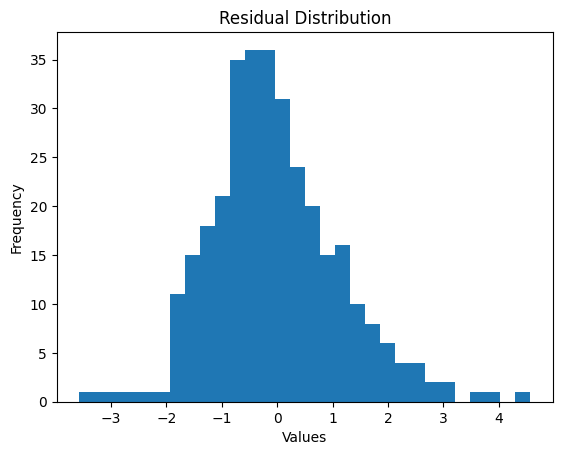

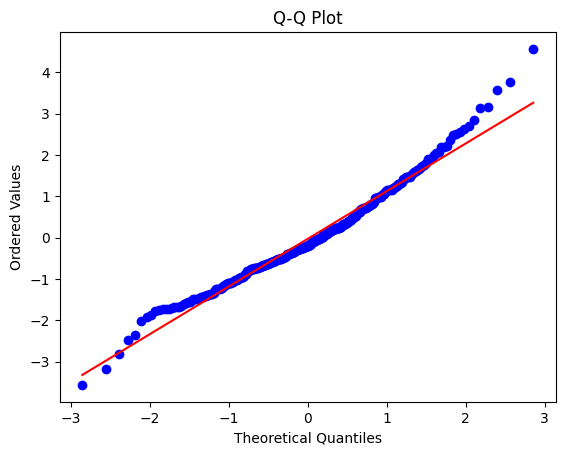

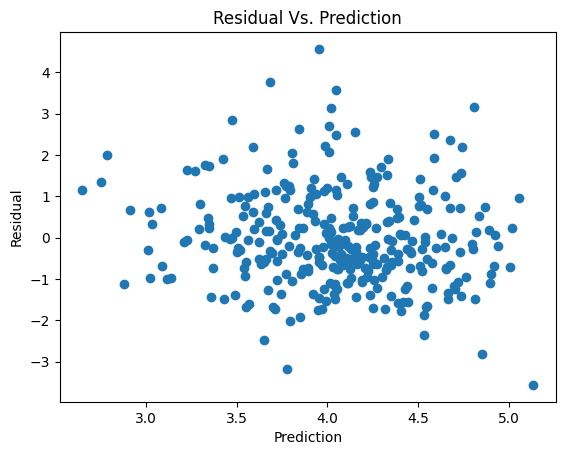

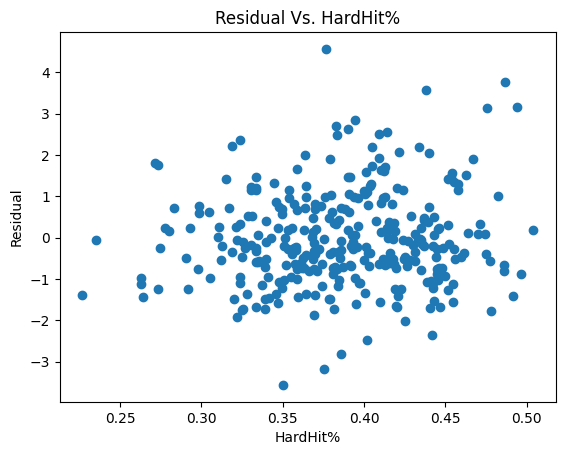

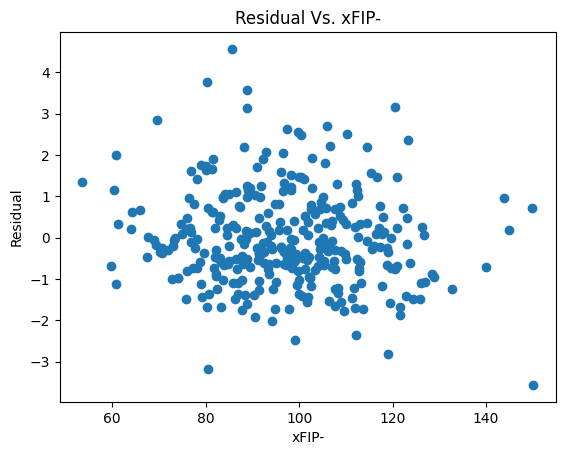

In [108]:
visualize_results(y_validation, yhat_base, X_validation)

## Step 10 - Linear Model Tuning(Ridge(L2) Lasso(L1), ElasticNet(L1 + L2))

In [109]:
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.model_selection import KFold, GridSearchCV

ridge_pipe = build_model(X_train, Ridge(random_state=42))
lasso_pipe = build_model(X_train, Lasso(random_state=42))
elastic_pipe = build_model(X_train, ElasticNet(random_state=42))

cv = KFold(n_splits=5, shuffle=True, random_state=42)

rl_params = {
    'model__alpha': [.01, .05, .1, 1, 5, 10]
}

elast_params = {
    'model__alpha': [.01, .05, .1, 1, 5, 10],
    'model__l1_ratio': [.1, .3, .5, .7, .9]
}

ridge_grid = GridSearchCV(ridge_pipe, param_grid= rl_params, scoring='neg_mean_absolute_error', cv=cv)
lasso_grid = GridSearchCV(lasso_pipe, param_grid=rl_params, scoring='neg_mean_absolute_error', cv=cv)
elastic_grid = GridSearchCV(elastic_pipe, param_grid=elast_params, scoring='neg_mean_absolute_error', cv=cv)

ridge_grid.fit(X_train, y_train)
lasso_grid.fit(X_train, y_train)
elastic_grid.fit(X_train, y_train)

print(f"Ridge Best params: {ridge_grid.best_params_}")
print(f"Lasso Best params: {lasso_grid.best_params_}")
print(f"ElasticNet Best params: {elastic_grid.best_params_}")

yhat_ridge = ridge_grid.predict(X_validation)
yhat_lasso = lasso_grid.predict(X_validation)
yhat_elastic = elastic_grid.predict(X_validation)

model_results("Ridge", y_validation, yhat_ridge, results)
model_results("Lasso", y_validation, yhat_lasso, results)
model_results("ElasticNet", y_validation, yhat_elastic, results)

Ridge Best params: {'model__alpha': 10}
Lasso Best params: {'model__alpha': 0.05}
ElasticNet Best params: {'model__alpha': 0.1, 'model__l1_ratio': 0.5}
Ridge results:
MAE: 0.8970706862464488
RMSE: 1.1592969084600642
R2: 0.05541332543066002
MAPE: 0.2627360683000444
Lasso results:
MAE: 0.8895239863823744
RMSE: 1.1568745048610434
R2: 0.05935671478258764
MAPE: 0.2622032574932732
ElasticNet results:
MAE: 0.8888028958326484
RMSE: 1.1559133993692714
R2: 0.06091899640962262
MAPE: 0.26206239550086197


### Lasso Feature Removal

In [110]:
coefs = lasso_grid.best_estimator_.named_steps['model'].coef_
names = lasso_grid.best_estimator_.named_steps['transform'].get_feature_names_out()


scores = list(zip(names, coefs))

zeroed = list(filter(lambda x: x[1] == 0, scores))
zeroed

[('feature_pipe__QS', np.float64(0.0)),
 ('feature_pipe__LA', np.float64(0.0)),
 ('feature_pipe__HardHit%', np.float64(0.0)),
 ('feature_pipe__K/BB+', np.float64(-0.0)),
 ('feature_pipe__LD%+', np.float64(0.0))]

## Step 11 - Tree Model Tuning

In [111]:
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

rf_pipe = build_model(X_train, RandomForestRegressor(random_state=42))
xg_pipe = build_model(X_train, XGBRegressor(random_state=42))

rf_params = {
    'model__n_estimators': [100, 200, 300],
    'model__max_depth': [5, 10, 15, None],
    'model__min_samples_split': [2, 5, 10]
}

xg_params = {
    'model__n_estimators': [100, 200, 300],
    'model__learning_rate': [.01, .05, .1, .3],
    'model__max_depth': [3, 5, 7]
}

rf_grid = GridSearchCV(rf_pipe, param_grid=rf_params, scoring='neg_mean_absolute_error', cv=cv)
xg_grid = GridSearchCV(xg_pipe, param_grid=xg_params, scoring='neg_mean_absolute_error', cv=cv)

rf_grid.fit(X_train, y_train)
xg_grid.fit(X_train, y_train)

rf_yhat = rf_grid.predict(X_validation)
xg_yhat = xg_grid.predict(X_validation)

print(f"Random Forest best params: {rf_grid.best_params_}")
print(f"XGBoost best params: {xg_grid.best_params_}")

model_results("Random Forest", y_validation, rf_yhat, results)
model_results("XGBoost", y_validation, xg_yhat, results)

Random Forest best params: {'model__max_depth': 5, 'model__min_samples_split': 10, 'model__n_estimators': 300}
XGBoost best params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 200}
Random Forest results:
MAE: 0.9040262583132805
RMSE: 1.1646901929934184
R2: 0.04660406386186422
MAPE: 0.2640748883606946
XGBoost results:
MAE: 0.8914439508435431
RMSE: 1.1524671426078636
R2: 0.0665102281802028
MAPE: 0.2617964877135058


In [112]:
print(f"Random Forest best params: {rf_grid.best_params_}")
print(f"XGBoost best params: {xg_grid.best_params_}")

model_results("Random Forest", y_validation, rf_yhat, results)
model_results("XGBoost", y_validation, xg_yhat, results)

Random Forest best params: {'model__max_depth': 5, 'model__min_samples_split': 10, 'model__n_estimators': 300}
XGBoost best params: {'model__learning_rate': 0.01, 'model__max_depth': 3, 'model__n_estimators': 200}
Random Forest results:
MAE: 0.9040262583132805
RMSE: 1.1646901929934184
R2: 0.04660406386186422
MAPE: 0.2640748883606946
XGBoost results:
MAE: 0.8914439508435431
RMSE: 1.1524671426078636
R2: 0.0665102281802028
MAPE: 0.2617964877135058


## Step 12 - Model Results

In [113]:
validation_results = pd.DataFrame(results).sort_values(by='MAE')
validation_results

,Model,MAE,RMSE,R2,MAPE
3,ElasticNet,0.888803,1.155913,0.060919,0.262062
2,Lasso,0.889524,1.156875,0.059357,0.262203
7,XGBoost,0.891444,1.152467,0.066510,0.261796
5,XGBoost,0.891444,1.152467,0.066510,0.261796
1,Ridge,0.897071,1.159297,0.055413,0.262736
0,Linear Regression,0.898190,1.159888,0.054449,0.263012
4,Random Forest,0.904026,1.164690,0.046604,0.264075
6,Random Forest,0.904026,1.164690,0.046604,0.264075


## Step 13 - Test Set Results

In [114]:
best_model = elastic_grid.best_estimator_

best_y_hat = best_model.predict(X_test)

model_results("Best Model (Test)", y_test, best_y_hat, [])

Best Model (Test) results:
MAE: 0.9394067264171458
RMSE: 1.1809471533728626
R2: 0.1309411525621198
MAPE: 0.2664991301767466


## Step 14 - Save Model

In [115]:
from joblib import dump

dump(best_model, "best_model.joblib")

['best_model.joblib']